In [ ]:
def run_multilabel_cv(
    train_full_df,
    test_labeled_df,
    test_unlabeled_df,
    text_col,
    output_dir,
):
    os.makedirs(output_dir, exist_ok=True)
    use_pin_memory = torch.cuda.is_available()

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    oof_records = []
    fold_test_probs = []
    fold_unlabeled_probs = []
    fold_stats = []

    total_training_examples_seen = 0
    total_train_seconds_start = time.perf_counter()
    all_epoch_seconds = []
    peak_gpu_memories = []

    print(f"Running multilabel CV with {N_FOLDS} folds and {EPOCHS_MULTILABEL} epochs per fold.")
    print(f"Total training rows available for CV: {len(train_full_df):,}")

    for fold_num, (tr_idx, va_idx) in enumerate(kf.split(train_full_df), start=1):
        fold_dir = os.path.join(output_dir, f"fold_{fold_num}")
        os.makedirs(fold_dir, exist_ok=True)

        fold_train_df = train_full_df.iloc[tr_idx].copy()
        fold_val_df = train_full_df.iloc[va_idx].copy()

        print(f"\nFold {fold_num}/{N_FOLDS}")
        print(f"  Train rows: {len(fold_train_df):,}")
        print(f"  Validation rows: {len(fold_val_df):,}")

        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=len(LABEL_COLS),
            problem_type="multi_label_classification",
        )
        model.to(device)

        total_params, trainable_params = parameter_counts(model)

        train_dataset = ToxicDataset(
            fold_train_df[["id", text_col] + LABEL_COLS].copy(),
            tokenizer,
            text_col,
            LABEL_COLS,
            MAX_LENGTH,
        )
        val_dataset = ToxicDataset(
            fold_val_df[["id", text_col] + LABEL_COLS].copy(),
            tokenizer,
            text_col,
            LABEL_COLS,
            MAX_LENGTH,
        )
        test_labeled_dataset = ToxicDataset(
            test_labeled_df[["id", text_col] + LABEL_COLS].copy(),
            tokenizer,
            text_col,
            LABEL_COLS,
            MAX_LENGTH,
        )
        test_unlabeled_dataset = ToxicDataset(
            test_unlabeled_df[["id", text_col]].copy(),
            tokenizer,
            text_col,
            None,
            MAX_LENGTH,
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=TRAIN_BATCH_SIZE,
            shuffle=True,
            pin_memory=use_pin_memory,
            num_workers=NUM_WORKERS,
        )
        val_loader = DataLoader(
            val_dataset,
            batch_size=EVAL_BATCH_SIZE,
            shuffle=False,
            pin_memory=use_pin_memory,
            num_workers=NUM_WORKERS,
        )
        test_labeled_loader = DataLoader(
            test_labeled_dataset,
            batch_size=EVAL_BATCH_SIZE,
            shuffle=False,
            pin_memory=use_pin_memory,
            num_workers=NUM_WORKERS,
        )
        test_unlabeled_loader = DataLoader(
            test_unlabeled_dataset,
            batch_size=EVAL_BATCH_SIZE,
            shuffle=False,
            pin_memory=use_pin_memory,
            num_workers=NUM_WORKERS,
        )

        optimizer = AdamW(model.parameters(), lr=LR)

        epoch_losses = []
        val_map_history = []
        best_val_map = -1
        best_dir = os.path.join(fold_dir, "best_checkpoint")

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats(device)

        for epoch in range(EPOCHS_MULTILABEL):
            model.train()
            total_loss = 0.0
            epoch_start = time.perf_counter()

            loop = tqdm(
                train_loader,
                desc=f"multilabel fold {fold_num} | Epoch {epoch+1}/{EPOCHS_MULTILABEL}",
                leave=False
            )

            for batch in loop:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                optimizer.zero_grad()
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels=labels
                )
                loss = outputs.loss
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                loop.set_postfix(loss=loss.item())

            avg_loss = total_loss / max(len(train_loader), 1)
            epoch_losses.append(avg_loss)

            epoch_seconds = time.perf_counter() - epoch_start
            all_epoch_seconds.append(epoch_seconds)
            total_training_examples_seen += len(fold_train_df)

            val_prob, val_true = evaluate_model(model, val_loader, device)
            val_metrics, _ = compute_multilabel_metrics(val_true, val_prob, LABEL_COLS, threshold=0.5)
            val_map = val_metrics["mean_average_precision"] if val_metrics["mean_average_precision"] is not None else -1
            val_map_history.append(val_map)

            print(
                f"fold={fold_num} epoch={epoch+1} "
                f"train_loss={avg_loss:.6f} "
                f"val_mAP={val_map:.6f} "
                f"train_rows={len(fold_train_df):,}"
            )

            if val_map > best_val_map:
                best_val_map = val_map
                if os.path.exists(best_dir):
                    shutil.rmtree(best_dir)
                model.save_pretrained(best_dir)
                tokenizer.save_pretrained(best_dir)

        peak_gpu_memories.append(
            float(torch.cuda.max_memory_allocated(device) / (1024 ** 2))
            if torch.cuda.is_available() else None
        )

        plot_loss_curve(
            epoch_losses,
            os.path.join(fold_dir, "training_loss_curve.png"),
            f"Training Loss by Epoch: multilabel fold {fold_num}"
        )
        plot_metric_curve(
            val_map_history,
            os.path.join(fold_dir, "validation_mean_average_precision_curve.png"),
            f"Validation mAP by Epoch: multilabel fold {fold_num}",
            "Mean Average Precision"
        )

        best_model = AutoModelForSequenceClassification.from_pretrained(best_dir)
        best_model.to(device)

        val_prob, val_true = evaluate_model(best_model, val_loader, device)
        test_prob, test_true = evaluate_model(best_model, test_labeled_loader, device)
        unlabeled_prob, _ = evaluate_model(best_model, test_unlabeled_loader, device)

        val_metrics, val_pred = compute_multilabel_metrics(val_true, val_prob, LABEL_COLS, threshold=0.5)
        test_metrics, test_pred = compute_multilabel_metrics(test_true, test_prob, LABEL_COLS, threshold=0.5)

        val_out = pd.concat(
            [
                fold_val_df[["id", text_col]].reset_index(drop=True),
                pd.DataFrame(val_true.astype(int), columns=[f"{c}_true" for c in LABEL_COLS]),
                pd.DataFrame(val_prob, columns=[f"{c}_prob" for c in LABEL_COLS]),
                pd.DataFrame(val_pred, columns=[f"{c}_pred_at_0_5" for c in LABEL_COLS]),
            ],
            axis=1,
        )
        val_out["fold"] = fold_num
        val_out.to_csv(os.path.join(fold_dir, "validation_predictions.csv"), index=False)
        oof_records.append(val_out)

        test_out = pd.concat(
            [
                test_labeled_df[["id", text_col]].reset_index(drop=True),
                pd.DataFrame(test_true.astype(int), columns=[f"{c}_true" for c in LABEL_COLS]),
                pd.DataFrame(test_prob, columns=[f"{c}_prob" for c in LABEL_COLS]),
                pd.DataFrame(test_pred, columns=[f"{c}_pred_at_0_5" for c in LABEL_COLS]),
            ],
            axis=1,
        )
        test_out.to_csv(os.path.join(fold_dir, "test_labeled_predictions.csv"), index=False)

        unlabeled_pred = (unlabeled_prob >= 0.5).astype(int)
        unlabeled_out = pd.concat(
            [
                test_unlabeled_df[["id", text_col]].reset_index(drop=True),
                pd.DataFrame(unlabeled_prob, columns=[f"{c}_prob" for c in LABEL_COLS]),
                pd.DataFrame(unlabeled_pred, columns=[f"{c}_pred_at_0_5" for c in LABEL_COLS]),
            ],
            axis=1,
        )
        unlabeled_out.to_csv(os.path.join(fold_dir, "test_predictions.csv"), index=False)

        save_json(val_metrics, os.path.join(fold_dir, "validation_metrics.json"))
        save_json(test_metrics, os.path.join(fold_dir, "test_labeled_metrics.json"))

        fold_test_probs.append(test_prob)
        fold_unlabeled_probs.append(unlabeled_prob)

        fold_stats.append({
            "fold": fold_num,
            "train_rows": len(fold_train_df),
            "validation_rows": len(fold_val_df),
            "validation_mean_average_precision": val_metrics["mean_average_precision"],
            "test_mean_average_precision": test_metrics["mean_average_precision"],
            "validation_micro_f1_at_0_5": val_metrics["micro_f1_at_0_5"],
            "validation_macro_f1_at_0_5": val_metrics["macro_f1_at_0_5"],
            "test_micro_f1_at_0_5": test_metrics["micro_f1_at_0_5"],
            "test_macro_f1_at_0_5": test_metrics["macro_f1_at_0_5"],
            "parameter_count": total_params,
            "trainable_parameter_count": trainable_params,
        })

    total_train_seconds = time.perf_counter() - total_train_seconds_start

    oof_df = pd.concat(oof_records, axis=0).sort_values("id").reset_index(drop=True)
    oof_df.to_csv(os.path.join(output_dir, "cv_validation_predictions_oof.csv"), index=False)

    oof_true = oof_df[[f"{c}_true" for c in LABEL_COLS]].values
    oof_prob = oof_df[[f"{c}_prob" for c in LABEL_COLS]].values
    oof_metrics, _ = compute_multilabel_metrics(oof_true, oof_prob, LABEL_COLS, threshold=0.5)
    save_json(oof_metrics, os.path.join(output_dir, "cv_validation_metrics_oof.json"))

    mean_test_prob = np.mean(np.stack(fold_test_probs, axis=0), axis=0)
    test_true = test_labeled_df[LABEL_COLS].values
    test_metrics, test_pred = compute_multilabel_metrics(test_true, mean_test_prob, LABEL_COLS, threshold=0.5)
    save_json(test_metrics, os.path.join(output_dir, "test_labeled_metrics.json"))

    aggregate_test_out = pd.concat(
        [
            test_labeled_df[["id", text_col]].reset_index(drop=True),
            pd.DataFrame(test_true.astype(int), columns=[f"{c}_true" for c in LABEL_COLS]),
            pd.DataFrame(mean_test_prob, columns=[f"{c}_prob" for c in LABEL_COLS]),
            pd.DataFrame(test_pred, columns=[f"{c}_pred_at_0_5" for c in LABEL_COLS]),
        ],
        axis=1,
    )
    aggregate_test_out.to_csv(os.path.join(output_dir, "test_labeled_predictions.csv"), index=False)

    mean_unlabeled_prob = np.mean(np.stack(fold_unlabeled_probs, axis=0), axis=0)
    unlabeled_pred = (mean_unlabeled_prob >= 0.5).astype(int)
    aggregate_unlabeled_out = pd.concat(
        [
            test_unlabeled_df[["id", text_col]].reset_index(drop=True),
            pd.DataFrame(mean_unlabeled_prob, columns=[f"{c}_prob" for c in LABEL_COLS]),
            pd.DataFrame(unlabeled_pred, columns=[f"{c}_pred_at_0_5" for c in LABEL_COLS]),
        ],
        axis=1,
    )
    aggregate_unlabeled_out.to_csv(os.path.join(output_dir, "test_predictions.csv"), index=False)

    fold_summary_df = pd.DataFrame(fold_stats)
    fold_summary_df.to_csv(os.path.join(output_dir, "cv_fold_summary.csv"), index=False)

    plt.figure(figsize=(10, 5))
    plt.bar(fold_summary_df["fold"].astype(str), fold_summary_df["validation_mean_average_precision"])
    plt.title("Multilabel CV: Validation Mean Average Precision by Fold")
    plt.xlabel("Fold")
    plt.ylabel("Validation mAP")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "cv_validation_map_by_fold.png"), dpi=200)
    plt.close()

    test_ap_values = [test_metrics["per_label"][label]["average_precision"] for label in LABEL_COLS]
    plt.figure(figsize=(11, 6))
    plt.bar(LABEL_COLS, test_ap_values)
    plt.title("Multilabel Ensemble: Test Average Precision by Label")
    plt.ylabel("Average Precision")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "test_average_precision_by_label.png"), dpi=200)
    plt.close()

    run_config = {
        "variant_name": "multilabel_distilbert_cv",
        "task_type": "multilabel",
        "selection_metric": "validation_mean_average_precision",
        "cv_design": f"{N_FOLDS}-fold CV",
        "expected_train_fraction_per_fold": (N_FOLDS - 1) / N_FOLDS,
        "expected_validation_fraction_per_fold": 1 / N_FOLDS,
        "model_name": MODEL_NAME,
        "n_folds": N_FOLDS,
        "epochs": EPOCHS_MULTILABEL,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "eval_batch_size": EVAL_BATCH_SIZE,
        "max_length": MAX_LENGTH,
        "learning_rate": LR,
        "train_rows_total": len(train_full_df),
        "test_labeled_rows": len(test_labeled_df),
        "test_unlabeled_rows": len(test_unlabeled_df),
    }
    save_json(run_config, os.path.join(output_dir, "run_config.json"))

    example_model = AutoModelForSequenceClassification.from_pretrained(
        os.path.join(output_dir, "fold_1", "best_checkpoint")
    )
    total_params, trainable_params = parameter_counts(example_model)

    run_stats = RunStats(
        variant_name="multilabel_distilbert_cv",
        task_type="multilabel",
        target_label=None,
        train_rows=len(train_full_df),
        val_rows=len(train_full_df),
        test_rows=len(test_labeled_df),
        epochs=EPOCHS_MULTILABEL,
        train_batch_size=TRAIN_BATCH_SIZE,
        eval_batch_size=EVAL_BATCH_SIZE,
        max_length=MAX_LENGTH,
        learning_rate=LR,
        total_train_seconds=float(total_train_seconds),
        avg_epoch_seconds=float(np.mean(all_epoch_seconds)),
        samples_per_second=float(total_training_examples_seen / max(total_train_seconds, 1e-9)),
        max_gpu_memory_mb=float(np.nanmax([m if m is not None else np.nan for m in peak_gpu_memories])) if len(peak_gpu_memories) > 0 else None,
        parameter_count=total_params,
        trainable_parameter_count=trainable_params,
        validation_main_metric=oof_metrics["mean_average_precision"],
        test_main_metric=test_metrics["mean_average_precision"],
    )
    save_json(asdict(run_stats), os.path.join(output_dir, "run_stats.json"))
    return run_stats

In [ ]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

def save_json(obj, path: str) -> None:
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

def detect_text_col(df: pd.DataFrame) -> str:
    candidates = [
        "comment_text_transformer",
        "comment_text",
        "comment_text_raw",
        "comment_text_clean",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    raise ValueError("No recognized text column found.")

def parameter_counts(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

class ToxicDataset(Dataset):
    def __init__(self, dataframe, tokenizer, text_col, label_cols, max_len):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.text_col = text_col
        self.label_cols = label_cols
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row[self.text_col])

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )

        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
        }

        if self.label_cols is not None:
            labels = row[self.label_cols].values.astype(np.float32)
            item["labels"] = torch.tensor(labels, dtype=torch.float)

        return item

def evaluate_model(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            probs = torch.sigmoid(outputs.logits).detach().cpu().numpy()
            all_probs.append(probs)

            if "labels" in batch:
                all_labels.append(batch["labels"].detach().cpu().numpy())

    y_prob = np.vstack(all_probs)
    y_true = np.vstack(all_labels) if len(all_labels) > 0 else None
    return y_prob, y_true

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "threshold": float(threshold),
        "average_precision": float(average_precision_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "roc_auc": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) > 1 else None,
        "precision_at_0_5": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_at_0_5": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1_at_0_5": float(f1_score(y_true, y_pred, zero_division=0)),
        "positive_rate_true": float(np.mean(y_true)),
        "positive_rate_pred_at_0_5": float(np.mean(y_pred)),
        "classification_report_at_0_5": classification_report(y_true, y_pred, output_dict=True, zero_division=0),
    }
    return metrics, y_pred

def compute_multilabel_metrics(y_true, y_prob, labels, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    per_label = {}
    ap_list = []
    auc_list = []

    for i, label in enumerate(labels):
        label_true = y_true[:, i]
        label_prob = y_prob[:, i]
        label_pred = y_pred[:, i]

        ap = average_precision_score(label_true, label_prob) if len(np.unique(label_true)) > 1 else None
        auc = roc_auc_score(label_true, label_prob) if len(np.unique(label_true)) > 1 else None

        per_label[label] = {
            "average_precision": float(ap) if ap is not None else None,
            "roc_auc": float(auc) if auc is not None else None,
            "precision_at_0_5": float(precision_score(label_true, label_pred, zero_division=0)),
            "recall_at_0_5": float(recall_score(label_true, label_pred, zero_division=0)),
            "f1_at_0_5": float(f1_score(label_true, label_pred, zero_division=0)),
            "positive_rate_true": float(np.mean(label_true)),
            "positive_rate_pred_at_0_5": float(np.mean(label_pred)),
            "classification_report_at_0_5": classification_report(label_true, label_pred, output_dict=True, zero_division=0),
        }

        if ap is not None:
            ap_list.append(ap)
        if auc is not None:
            auc_list.append(auc)

    results = {
        "mean_average_precision": float(np.mean(ap_list)) if len(ap_list) > 0 else None,
        "mean_roc_auc": float(np.mean(auc_list)) if len(auc_list) > 0 else None,
        "micro_f1_at_0_5": float(f1_score(y_true, y_pred, average="micro", zero_division=0)),
        "macro_f1_at_0_5": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "per_label": per_label,
    }
    return results, y_pred

def plot_loss_curve(losses, output_path, title):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(losses) + 1), losses, marker="o")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Average BCE Loss")
    plt.xticks(range(1, len(losses) + 1))
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()

def plot_metric_curve(values, output_path, title, ylabel):
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(values) + 1), values, marker="o")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.xticks(range(1, len(values) + 1))
    plt.tight_layout()
    plt.savefig(output_path, dpi=200)
    plt.close()

@dataclass
class RunStats:
    variant_name: str
    task_type: str
    target_label: str | None
    train_rows: int
    val_rows: int
    test_rows: int
    epochs: int
    train_batch_size: int
    eval_batch_size: int
    max_length: int
    learning_rate: float
    total_train_seconds: float
    avg_epoch_seconds: float
    samples_per_second: float
    max_gpu_memory_mb: float | None
    parameter_count: int
    trainable_parameter_count: int
    validation_main_metric: float | None
    test_main_metric: float | None

def train_single_binary_model(
    variant_name,
    target_label,
    train_df,
    val_df,
    test_labeled_df,
    test_unlabeled_df,
    text_col,
    output_dir,
):
    os.makedirs(output_dir, exist_ok=True)
    use_pin_memory = torch.cuda.is_available()
    label_cols = [target_label]

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=1,
        problem_type="multi_label_classification",
    )
    model.to(device)

    total_params, trainable_params = parameter_counts(model)

    train_dataset = ToxicDataset(train_df[["id", text_col] + label_cols].copy(), tokenizer, text_col, label_cols, MAX_LENGTH)
    val_dataset = ToxicDataset(val_df[["id", text_col] + label_cols].copy(), tokenizer, text_col, label_cols, MAX_LENGTH)
    test_labeled_dataset = ToxicDataset(test_labeled_df[["id", text_col] + label_cols].copy(), tokenizer, text_col, label_cols, MAX_LENGTH)
    test_unlabeled_dataset = ToxicDataset(test_unlabeled_df[["id", text_col]].copy(), tokenizer, text_col, None, MAX_LENGTH)

    train_loader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True, pin_memory=use_pin_memory, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, pin_memory=use_pin_memory, num_workers=NUM_WORKERS)
    test_labeled_loader = DataLoader(test_labeled_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, pin_memory=use_pin_memory, num_workers=NUM_WORKERS)
    test_unlabeled_loader = DataLoader(test_unlabeled_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, pin_memory=use_pin_memory, num_workers=NUM_WORKERS)

    optimizer = AdamW(model.parameters(), lr=LR)
    epoch_losses = []
    val_ap_history = []

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats(device)

    best_val_ap = -1
    best_dir = os.path.join(output_dir, "best_checkpoint")
    total_train_seconds_start = time.perf_counter()
    epoch_seconds = []

    for epoch in range(EPOCHS_BINARY):
        model.train()
        total_loss = 0.0
        epoch_start = time.perf_counter()

        loop = tqdm(train_loader, desc=f"{variant_name} | Epoch {epoch+1}/{EPOCHS_BINARY}", leave=False)
        for batch in loop:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())

        avg_loss = total_loss / max(len(train_loader), 1)
        epoch_losses.append(avg_loss)
        epoch_seconds.append(time.perf_counter() - epoch_start)

        val_prob, val_true = evaluate_model(model, val_loader, device)
        val_metrics, _ = compute_binary_metrics(val_true[:, 0], val_prob[:, 0], threshold=0.5)
        val_ap = val_metrics["average_precision"] if val_metrics["average_precision"] is not None else -1
        val_ap_history.append(val_ap)

        print(f"{variant_name} | epoch={epoch+1} | train_loss={avg_loss:.6f} | val_ap={val_ap:.6f}")

        if val_ap > best_val_ap:
            best_val_ap = val_ap
            if os.path.exists(best_dir):
                shutil.rmtree(best_dir)
            model.save_pretrained(best_dir)
            tokenizer.save_pretrained(best_dir)

    total_train_seconds = time.perf_counter() - total_train_seconds_start
    max_gpu_memory_mb = float(torch.cuda.max_memory_allocated(device) / (1024 ** 2)) if torch.cuda.is_available() else None

    plot_loss_curve(epoch_losses, os.path.join(output_dir, "training_loss_curve.png"), f"Training Loss by Epoch: {variant_name}")
    plot_metric_curve(val_ap_history, os.path.join(output_dir, "validation_average_precision_curve.png"), f"Validation AP by Epoch: {variant_name}", "Average Precision")

    best_model = AutoModelForSequenceClassification.from_pretrained(best_dir)
    best_model.to(device)

    val_prob, val_true = evaluate_model(best_model, val_loader, device)
    test_prob, test_true = evaluate_model(best_model, test_labeled_loader, device)
    unlabeled_prob, _ = evaluate_model(best_model, test_unlabeled_loader, device)

    val_metrics, val_pred = compute_binary_metrics(val_true[:, 0], val_prob[:, 0], threshold=0.5)
    test_metrics, test_pred = compute_binary_metrics(test_true[:, 0], test_prob[:, 0], threshold=0.5)
    unlabeled_pred = (unlabeled_prob[:, 0] >= 0.5).astype(int)

    val_out = val_df[["id", text_col, target_label]].copy().reset_index(drop=True)
    val_out.rename(columns={target_label: f"{target_label}_true"}, inplace=True)
    val_out[f"{target_label}_prob"] = val_prob[:, 0]
    val_out[f"{target_label}_pred_at_0_5"] = val_pred
    val_out.to_csv(os.path.join(output_dir, "validation_predictions.csv"), index=False)

    test_out = test_labeled_df[["id", text_col, target_label]].copy().reset_index(drop=True)
    test_out.rename(columns={target_label: f"{target_label}_true"}, inplace=True)
    test_out[f"{target_label}_prob"] = test_prob[:, 0]
    test_out[f"{target_label}_pred_at_0_5"] = test_pred
    test_out.to_csv(os.path.join(output_dir, "test_labeled_predictions.csv"), index=False)

    unlabeled_out = test_unlabeled_df[["id", text_col]].copy().reset_index(drop=True)
    unlabeled_out[f"{target_label}_prob"] = unlabeled_prob[:, 0]
    unlabeled_out[f"{target_label}_pred_at_0_5"] = unlabeled_pred
    unlabeled_out.to_csv(os.path.join(output_dir, "test_predictions.csv"), index=False)

    plt.figure(figsize=(8, 5))
    plt.hist(test_prob[:, 0], bins=40)
    plt.title(f"Predicted Probability Distribution: {target_label}")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "probability_histogram_test.png"), dpi=200)
    plt.close()

    save_json(val_metrics, os.path.join(output_dir, "validation_metrics.json"))
    save_json(test_metrics, os.path.join(output_dir, "test_labeled_metrics.json"))

    run_config = {
        "variant_name": variant_name,
        "task_type": "binary",
        "target_label": target_label,
        "selection_metric": "validation_average_precision",
        "model_name": MODEL_NAME,
        "epochs": EPOCHS_BINARY,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "eval_batch_size": EVAL_BATCH_SIZE,
        "max_length": MAX_LENGTH,
        "learning_rate": LR,
        "train_rows": len(train_df),
        "val_rows": len(val_df),
        "test_labeled_rows": len(test_labeled_df),
        "test_unlabeled_rows": len(test_unlabeled_df),
    }
    save_json(run_config, os.path.join(output_dir, "run_config.json"))

    run_stats = RunStats(
        variant_name=variant_name,
        task_type="binary",
        target_label=target_label,
        train_rows=len(train_df),
        val_rows=len(val_df),
        test_rows=len(test_labeled_df),
        epochs=EPOCHS_BINARY,
        train_batch_size=TRAIN_BATCH_SIZE,
        eval_batch_size=EVAL_BATCH_SIZE,
        max_length=MAX_LENGTH,
        learning_rate=LR,
        total_train_seconds=float(total_train_seconds),
        avg_epoch_seconds=float(np.mean(epoch_seconds)),
        samples_per_second=float((len(train_df) * EPOCHS_BINARY) / max(total_train_seconds, 1e-9)),
        max_gpu_memory_mb=max_gpu_memory_mb,
        parameter_count=total_params,
        trainable_parameter_count=trainable_params,
        validation_main_metric=val_metrics["average_precision"],
        test_main_metric=test_metrics["average_precision"],
    )
    save_json(asdict(run_stats), os.path.join(output_dir, "run_stats.json"))
    return run_stats

def run_multilabel_cv(
    train_full_df,
    test_labeled_df,
    test_unlabeled_df,
    text_col,
    output_dir,
):
    os.makedirs(output_dir, exist_ok=True)
    use_pin_memory = torch.cuda.is_available()

    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    oof_records = []
    fold_test_probs = []
    fold_unlabeled_probs = []
    fold_stats = []

    total_training_examples_seen = 0
    total_train_seconds_start = time.perf_counter()
    all_epoch_seconds = []
    peak_gpu_memories = []

    for fold_num, (tr_idx, va_idx) in enumerate(kf.split(train_full_df), start=1):
        fold_dir = os.path.join(output_dir, f"fold_{fold_num}")
        os.makedirs(fold_dir, exist_ok=True)

        fold_train_df = train_full_df.iloc[tr_idx].copy()
        fold_val_df = train_full_df.iloc[va_idx].copy()

        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        model = AutoModelForSequenceClassification.from_pretrained(
            MODEL_NAME,
            num_labels=len(LABEL_COLS),
            problem_type="multi_label_classification",
        )
        model.to(device)

        total_params, trainable_params = parameter_counts(model)

        train_dataset = ToxicDataset(fold_train_df[["id", text_col] + LABEL_COLS].copy(), tokenizer, text_col, LABEL_COLS, MAX_LENGTH)
        val_dataset = ToxicDataset(fold_val_df[["id", text_col] + LABEL_COLS].copy(), tokenizer, text_col, LABEL_COLS, MAX_LENGTH)
        test_labeled_dataset = ToxicDataset(test_labeled_df[["id", text_col] + LABEL_COLS].copy(), tokenizer, text_col, LABEL_COLS, MAX_LENGTH)
        test_unlabeled_dataset = ToxicDataset(test_unlabeled_df[["id", text_col]].copy(), tokenizer, text_col, None, MAX_LENGTH)

        train_loader = DataLoader(train_dataset, batch_size=TRAIN_BATCH_SIZE, shuffle=True, pin_memory=use_pin_memory, num_workers=NUM_WORKERS)
        val_loader = DataLoader(val_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, pin_memory=use_pin_memory, num_workers=NUM_WORKERS)
        test_labeled_loader = DataLoader(test_labeled_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, pin_memory=use_pin_memory, num_workers=NUM_WORKERS)
        test_unlabeled_loader = DataLoader(test_unlabeled_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, pin_memory=use_pin_memory, num_workers=NUM_WORKERS)

        optimizer = AdamW(model.parameters(), lr=LR)

        epoch_losses = []
        val_map_history = []
        best_val_map = -1
        best_dir = os.path.join(fold_dir, "best_checkpoint")

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats(device)

        for epoch in range(EPOCHS_MULTILABEL):
            model.train()
            total_loss = 0.0
            epoch_start = time.perf_counter()

            loop = tqdm(train_loader, desc=f"multilabel fold {fold_num} | Epoch {epoch+1}/{EPOCHS_MULTILABEL}", leave=False)
            for batch in loop:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                labels = batch["labels"].to(device)

                optimizer.zero_grad()
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                loss = outputs.loss
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                loop.set_postfix(loss=loss.item())

            avg_loss = total_loss / max(len(train_loader), 1)
            epoch_losses.append(avg_loss)
            epoch_seconds = time.perf_counter() - epoch_start
            all_epoch_seconds.append(epoch_seconds)
            total_training_examples_seen += len(fold_train_df)

            val_prob, val_true = evaluate_model(model, val_loader, device)
            val_metrics, _ = compute_multilabel_metrics(val_true, val_prob, LABEL_COLS, threshold=0.5)
            val_map = val_metrics["mean_average_precision"] if val_metrics["mean_average_precision"] is not None else -1
            val_map_history.append(val_map)

            print(f"multilabel fold={fold_num} epoch={epoch+1} train_loss={avg_loss:.6f} val_mAP={val_map:.6f}")

            if val_map > best_val_map:
                best_val_map = val_map
                if os.path.exists(best_dir):
                    shutil.rmtree(best_dir)
                model.save_pretrained(best_dir)
                tokenizer.save_pretrained(best_dir)

        peak_gpu_memories.append(float(torch.cuda.max_memory_allocated(device) / (1024 ** 2)) if torch.cuda.is_available() else None)

        plot_loss_curve(epoch_losses, os.path.join(fold_dir, "training_loss_curve.png"), f"Training Loss by Epoch: multilabel fold {fold_num}")
        plot_metric_curve(val_map_history, os.path.join(fold_dir, "validation_mean_average_precision_curve.png"), f"Validation mAP by Epoch: multilabel fold {fold_num}", "Mean Average Precision")

        best_model = AutoModelForSequenceClassification.from_pretrained(best_dir)
        best_model.to(device)

        val_prob, val_true = evaluate_model(best_model, val_loader, device)
        test_prob, test_true = evaluate_model(best_model, test_labeled_loader, device)
        unlabeled_prob, _ = evaluate_model(best_model, test_unlabeled_loader, device)

        val_metrics, val_pred = compute_multilabel_metrics(val_true, val_prob, LABEL_COLS, threshold=0.5)
        test_metrics, test_pred = compute_multilabel_metrics(test_true, test_prob, LABEL_COLS, threshold=0.5)

        val_out = pd.concat(
            [
                fold_val_df[["id", text_col]].reset_index(drop=True),
                pd.DataFrame(val_true.astype(int), columns=[f"{c}_true" for c in LABEL_COLS]),
                pd.DataFrame(val_prob, columns=[f"{c}_prob" for c in LABEL_COLS]),
                pd.DataFrame(val_pred, columns=[f"{c}_pred_at_0_5" for c in LABEL_COLS]),
            ],
            axis=1
        )
        val_out["fold"] = fold_num
        val_out.to_csv(os.path.join(fold_dir, "validation_predictions.csv"), index=False)
        oof_records.append(val_out)

        test_out = pd.concat(
            [
                test_labeled_df[["id", text_col]].reset_index(drop=True),
                pd.DataFrame(test_true.astype(int), columns=[f"{c}_true" for c in LABEL_COLS]),
                pd.DataFrame(test_prob, columns=[f"{c}_prob" for c in LABEL_COLS]),
                pd.DataFrame(test_pred, columns=[f"{c}_pred_at_0_5" for c in LABEL_COLS]),
            ],
            axis=1
        )
        test_out.to_csv(os.path.join(fold_dir, "test_labeled_predictions.csv"), index=False)

        unlabeled_pred = (unlabeled_prob >= 0.5).astype(int)
        unlabeled_out = pd.concat(
            [
                test_unlabeled_df[["id", text_col]].reset_index(drop=True),
                pd.DataFrame(unlabeled_prob, columns=[f"{c}_prob" for c in LABEL_COLS]),
                pd.DataFrame(unlabeled_pred, columns=[f"{c}_pred_at_0_5" for c in LABEL_COLS]),
            ],
            axis=1
        )
        unlabeled_out.to_csv(os.path.join(fold_dir, "test_predictions.csv"), index=False)

        save_json(val_metrics, os.path.join(fold_dir, "validation_metrics.json"))
        save_json(test_metrics, os.path.join(fold_dir, "test_labeled_metrics.json"))

        fold_test_probs.append(test_prob)
        fold_unlabeled_probs.append(unlabeled_prob)

        fold_stats.append({
            "fold": fold_num,
            "validation_mean_average_precision": val_metrics["mean_average_precision"],
            "test_mean_average_precision": test_metrics["mean_average_precision"],
            "validation_micro_f1_at_0_5": val_metrics["micro_f1_at_0_5"],
            "validation_macro_f1_at_0_5": val_metrics["macro_f1_at_0_5"],
            "test_micro_f1_at_0_5": test_metrics["micro_f1_at_0_5"],
            "test_macro_f1_at_0_5": test_metrics["macro_f1_at_0_5"],
            "parameter_count": total_params,
            "trainable_parameter_count": trainable_params,
        })

    total_train_seconds = time.perf_counter() - total_train_seconds_start

    oof_df = pd.concat(oof_records, axis=0).sort_values("id").reset_index(drop=True)
    oof_df.to_csv(os.path.join(output_dir, "cv_validation_predictions_oof.csv"), index=False)

    oof_true = oof_df[[f"{c}_true" for c in LABEL_COLS]].values
    oof_prob = oof_df[[f"{c}_prob" for c in LABEL_COLS]].values
    oof_metrics, oof_pred = compute_multilabel_metrics(oof_true, oof_prob, LABEL_COLS, threshold=0.5)
    save_json(oof_metrics, os.path.join(output_dir, "cv_validation_metrics_oof.json"))

    mean_test_prob = np.mean(np.stack(fold_test_probs, axis=0), axis=0)
    test_true = test_labeled_df[LABEL_COLS].values
    test_metrics, test_pred = compute_multilabel_metrics(test_true, mean_test_prob, LABEL_COLS, threshold=0.5)
    save_json(test_metrics, os.path.join(output_dir, "test_labeled_metrics.json"))

    aggregate_test_out = pd.concat(
        [
            test_labeled_df[["id", text_col]].reset_index(drop=True),
            pd.DataFrame(test_true.astype(int), columns=[f"{c}_true" for c in LABEL_COLS]),
            pd.DataFrame(mean_test_prob, columns=[f"{c}_prob" for c in LABEL_COLS]),
            pd.DataFrame(test_pred, columns=[f"{c}_pred_at_0_5" for c in LABEL_COLS]),
        ],
        axis=1
    )
    aggregate_test_out.to_csv(os.path.join(output_dir, "test_labeled_predictions.csv"), index=False)

    mean_unlabeled_prob = np.mean(np.stack(fold_unlabeled_probs, axis=0), axis=0)
    unlabeled_pred = (mean_unlabeled_prob >= 0.5).astype(int)
    aggregate_unlabeled_out = pd.concat(
        [
            test_unlabeled_df[["id", text_col]].reset_index(drop=True),
            pd.DataFrame(mean_unlabeled_prob, columns=[f"{c}_prob" for c in LABEL_COLS]),
            pd.DataFrame(unlabeled_pred, columns=[f"{c}_pred_at_0_5" for c in LABEL_COLS]),
        ],
        axis=1
    )
    aggregate_unlabeled_out.to_csv(os.path.join(output_dir, "test_predictions.csv"), index=False)

    fold_summary_df = pd.DataFrame(fold_stats)
    fold_summary_df.to_csv(os.path.join(output_dir, "cv_fold_summary.csv"), index=False)

    plt.figure(figsize=(10, 5))
    plt.bar(fold_summary_df["fold"].astype(str), fold_summary_df["validation_mean_average_precision"])
    plt.title("Multilabel CV: Validation Mean Average Precision by Fold")
    plt.xlabel("Fold")
    plt.ylabel("Validation mAP")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "cv_validation_map_by_fold.png"), dpi=200)
    plt.close()

    test_ap_values = [test_metrics["per_label"][label]["average_precision"] for label in LABEL_COLS]
    plt.figure(figsize=(11, 6))
    plt.bar(LABEL_COLS, test_ap_values)
    plt.title("Multilabel Ensemble: Test Average Precision by Label")
    plt.ylabel("Average Precision")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "test_average_precision_by_label.png"), dpi=200)
    plt.close()

    run_config = {
        "variant_name": "multilabel_distilbert_cv",
        "task_type": "multilabel",
        "selection_metric": "validation_mean_average_precision",
        "model_name": MODEL_NAME,
        "n_folds": N_FOLDS,
        "epochs": EPOCHS_MULTILABEL,
        "train_batch_size": TRAIN_BATCH_SIZE,
        "eval_batch_size": EVAL_BATCH_SIZE,
        "max_length": MAX_LENGTH,
        "learning_rate": LR,
        "train_rows_total": len(train_full_df),
        "test_labeled_rows": len(test_labeled_df),
        "test_unlabeled_rows": len(test_unlabeled_df),
    }
    save_json(run_config, os.path.join(output_dir, "run_config.json"))

    example_model = AutoModelForSequenceClassification.from_pretrained(os.path.join(output_dir, "fold_1", "best_checkpoint"))
    total_params, trainable_params = parameter_counts(example_model)

    run_stats = RunStats(
        variant_name="multilabel_distilbert_cv",
        task_type="multilabel",
        target_label=None,
        train_rows=len(train_full_df),
        val_rows=len(train_full_df),
        test_rows=len(test_labeled_df),
        epochs=EPOCHS_MULTILABEL,
        train_batch_size=TRAIN_BATCH_SIZE,
        eval_batch_size=EVAL_BATCH_SIZE,
        max_length=MAX_LENGTH,
        learning_rate=LR,
        total_train_seconds=float(total_train_seconds),
        avg_epoch_seconds=float(np.mean(all_epoch_seconds)),
        samples_per_second=float((total_training_examples_seen * EPOCHS_MULTILABEL) / max(total_train_seconds, 1e-9)),
        max_gpu_memory_mb=float(np.nanmax([m if m is not None else np.nan for m in peak_gpu_memories])) if len(peak_gpu_memories) > 0 else None,
        parameter_count=total_params,
        trainable_parameter_count=trainable_params,
        validation_main_metric=oof_metrics["mean_average_precision"],
        test_main_metric=test_metrics["mean_average_precision"],
    )
    save_json(asdict(run_stats), os.path.join(output_dir, "run_stats.json"))
    return run_stats

In [ ]:
train_full = pd.read_parquet(TRAIN_PATH)
test_labeled = pd.read_parquet(TEST_LABELED_PATH)
test_unlabeled = pd.read_parquet(TEST_PATH)

TEXT_COL = detect_text_col(train_full)

print("Using text column:", TEXT_COL)
print("Loaded training data shape:", train_full.shape)
print("Loaded labeled test data shape:", test_labeled.shape)
print("Loaded unlabeled test data shape:", test_unlabeled.shape)

train_full = train_full[["id", TEXT_COL] + LABEL_COLS].dropna().copy()
train_full[TEXT_COL] = train_full[TEXT_COL].astype(str)

test_labeled = test_labeled[["id", TEXT_COL] + LABEL_COLS].dropna().copy()
test_labeled[TEXT_COL] = test_labeled[TEXT_COL].astype(str)

test_unlabeled = test_unlabeled[["id", TEXT_COL]].dropna().copy()
test_unlabeled[TEXT_COL] = test_unlabeled[TEXT_COL].astype(str)

# I only use a single split for the binary runs.
binary_train_df, binary_val_df = train_test_split(
    train_full,
    test_size=VAL_SIZE_BINARY,
    random_state=SEED,
    shuffle=True,
)

print("Binary train size:", len(binary_train_df))
print("Binary val size:", len(binary_val_df))

Using text column: comment_text_transformer
Loaded training data shape: (159571, 12)
Loaded labeled test data shape: (63978, 12)
Loaded unlabeled test data shape: (153164, 6)
Binary train size: 135635
Binary val size: 23936


In [ ]:
print("Total rows:", len(train_full))
print("Expected train rows per fold:", int(len(train_full) * 0.8))
print("Expected batches per epoch:", math.ceil(len(train_full) * 0.8 / TRAIN_BATCH_SIZE))

Total rows: 159571
Expected train rows per fold: 127656
Expected batches per epoch: 7979


In [ ]:
multilabel_stats = run_multilabel_cv(
    train_full_df=train_full,
    test_labeled_df=test_labeled,
    test_unlabeled_df=test_unlabeled,
    text_col=TEXT_COL,
    output_dir=FOLDERS["multilabel"],
)

multilabel_stats

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


multilabel fold=1 epoch=1 train_loss=0.049358 val_mAP=0.707914


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

multilabel fold=1 epoch=2 train_loss=0.034447 val_mAP=0.715401


...

multilabel fold=3 epoch=3 train_loss=0.026821 val_mAP=0.712003


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

RunStats(variant_name='multilabel_distilbert_cv', task_type='multilabel', target_label=None, train_rows=159571, val_rows=159571, test_rows=63978, epochs=3, train_batch_size=16, eval_batch_size=32, max_length=128, learning_rate=2e-05, total_train_seconds=1642.632747648, avg_epoch_seconds=129.96197754677783, samples_per_second=1748.581966427167, max_gpu_memory_mb=2781.27587890625, parameter_count=66958086, trainable_parameter_count=66958086, validation_main_metric=0.6929096954720659, test_main_metric=0.680587031044503)

In [ ]:
toxic_stats = train_single_binary_model(
    variant_name="binary_toxic",
    target_label="toxic",
    train_df=binary_train_df,
    val_df=binary_val_df,
    test_labeled_df=test_labeled,
    test_unlabeled_df=test_unlabeled,
    text_col=TEXT_COL,
    output_dir=FOLDERS["toxic"],
)

toxic_stats

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


binary_toxic | epoch=1 | train_loss=0.097123 | val_ap=0.916349


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

RunStats(variant_name='binary_toxic', task_type='binary', target_label='toxic', train_rows=135635, val_rows=23936, test_rows=63978, epochs=1, train_batch_size=16, eval_batch_size=32, max_length=128, learning_rate=2e-05, total_train_seconds=174.39727806499968, avg_epoch_seconds=165.15082009299977, samples_per_second=777.7357623061492, max_gpu_memory_mb=2521.8330078125, parameter_count=66954241, trainable_parameter_count=66954241, validation_main_metric=0.9163489584898518, test_main_metric=0.7967387763951077)

In [ ]:
severe_toxic_stats = train_single_binary_model(
    variant_name="binary_severe_toxic",
    target_label="severe_toxic",
    train_df=binary_train_df,
    val_df=binary_val_df,
    test_labeled_df=test_labeled,
    test_unlabeled_df=test_unlabeled,
    text_col=TEXT_COL,
    output_dir=FOLDERS["severe_toxic"],
)

severe_toxic_stats

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                             

binary_severe_toxic | epoch=1 | train_loss=0.025794 | val_ap=0.455167


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

RunStats(variant_name='binary_severe_toxic', task_type='binary', target_label='severe_toxic', train_rows=135635, val_rows=23936, test_rows=63978, epochs=1, train_batch_size=16, eval_batch_size=32, max_length=128, learning_rate=2e-05, total_train_seconds=174.40342082300003, avg_epoch_seconds=165.43124325899998, samples_per_second=777.7083692507061, max_gpu_memory_mb=2521.8330078125, parameter_count=66954241, trainable_parameter_count=66954241, validation_main_metric=0.4551674892058862, test_main_metric=0.3376288592521979)

In [ ]:
obscene_stats = train_single_binary_model(
    variant_name="binary_obscene",
    target_label="obscene",
    train_df=binary_train_df,
    val_df=binary_val_df,
    test_labeled_df=test_labeled,
    test_unlabeled_df=test_unlabeled,
    text_col=TEXT_COL,
    output_dir=FOLDERS["obscene"],
)

obscene_stats

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                             

binary_obscene | epoch=1 | train_loss=0.053175 | val_ap=0.914608


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

RunStats(variant_name='binary_obscene', task_type='binary', target_label='obscene', train_rows=135635, val_rows=23936, test_rows=63978, epochs=1, train_batch_size=16, eval_batch_size=32, max_length=128, learning_rate=2e-05, total_train_seconds=174.37673327699986, avg_epoch_seconds=165.32044138699985, samples_per_second=777.827393890571, max_gpu_memory_mb=2521.8330078125, parameter_count=66954241, trainable_parameter_count=66954241, validation_main_metric=0.9146080950166462, test_main_metric=0.7771188557186623)

In [ ]:
threat_stats = train_single_binary_model(
    variant_name="binary_threat",
    target_label="threat",
    train_df=binary_train_df,
    val_df=binary_val_df,
    test_labeled_df=test_labeled,
    test_unlabeled_df=test_unlabeled,
    text_col=TEXT_COL,
    output_dir=FOLDERS["threat"],
)

threat_stats

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                             

binary_threat | epoch=1 | train_loss=0.011366 | val_ap=0.463052


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

RunStats(variant_name='binary_threat', task_type='binary', target_label='threat', train_rows=135635, val_rows=23936, test_rows=63978, epochs=1, train_batch_size=16, eval_batch_size=32, max_length=128, learning_rate=2e-05, total_train_seconds=174.45232435499975, avg_epoch_seconds=165.44967056099995, samples_per_second=777.4903573310444, max_gpu_memory_mb=2521.8330078125, parameter_count=66954241, trainable_parameter_count=66954241, validation_main_metric=0.463051633889032, test_main_metric=0.5304504460636297)

In [ ]:
insult_stats = train_single_binary_model(
    variant_name="binary_insult",
    target_label="insult",
    train_df=binary_train_df,
    val_df=binary_val_df,
    test_labeled_df=test_labeled,
    test_unlabeled_df=test_unlabeled,
    text_col=TEXT_COL,
    output_dir=FOLDERS["insult"],
)

insult_stats

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


binary_insult | epoch=1 | train_loss=0.067040 | val_ap=0.832402


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

RunStats(variant_name='binary_insult', task_type='binary', target_label='insult', train_rows=135635, val_rows=23936, test_rows=63978, epochs=1, train_batch_size=16, eval_batch_size=32, max_length=128, learning_rate=2e-05, total_train_seconds=174.63525384099967, avg_epoch_seconds=165.4509687689997, samples_per_second=776.675940377375, max_gpu_memory_mb=2521.8330078125, parameter_count=66954241, trainable_parameter_count=66954241, validation_main_metric=0.8324016424638837, test_main_metric=0.7544504352224406)

In [ ]:
identity_hate_stats = train_single_binary_model(
    variant_name="binary_identity_hate",
    target_label="identity_hate",
    train_df=binary_train_df,
    val_df=binary_val_df,
    test_labeled_df=test_labeled,
    test_unlabeled_df=test_unlabeled,
    text_col=TEXT_COL,
    output_dir=FOLDERS["identity_hate"],
)

identity_hate_stats

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                             

binary_identity_hate | epoch=1 | train_loss=0.024015 | val_ap=0.568737


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

RunStats(variant_name='binary_identity_hate', task_type='binary', target_label='identity_hate', train_rows=135635, val_rows=23936, test_rows=63978, epochs=1, train_batch_size=16, eval_batch_size=32, max_length=128, learning_rate=2e-05, total_train_seconds=175.0917334159999, avg_epoch_seconds=165.77951907700026, samples_per_second=774.6510777738731, max_gpu_memory_mb=2521.8330078125, parameter_count=66954241, trainable_parameter_count=66954241, validation_main_metric=0.5687367446420807, test_main_metric=0.6676799884532869)

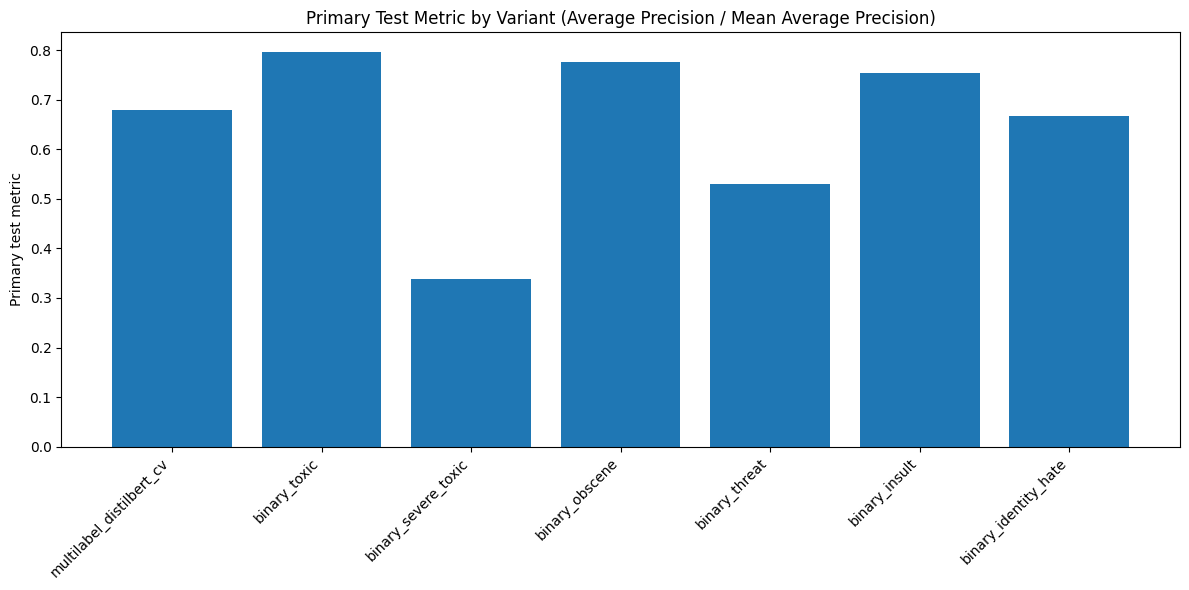

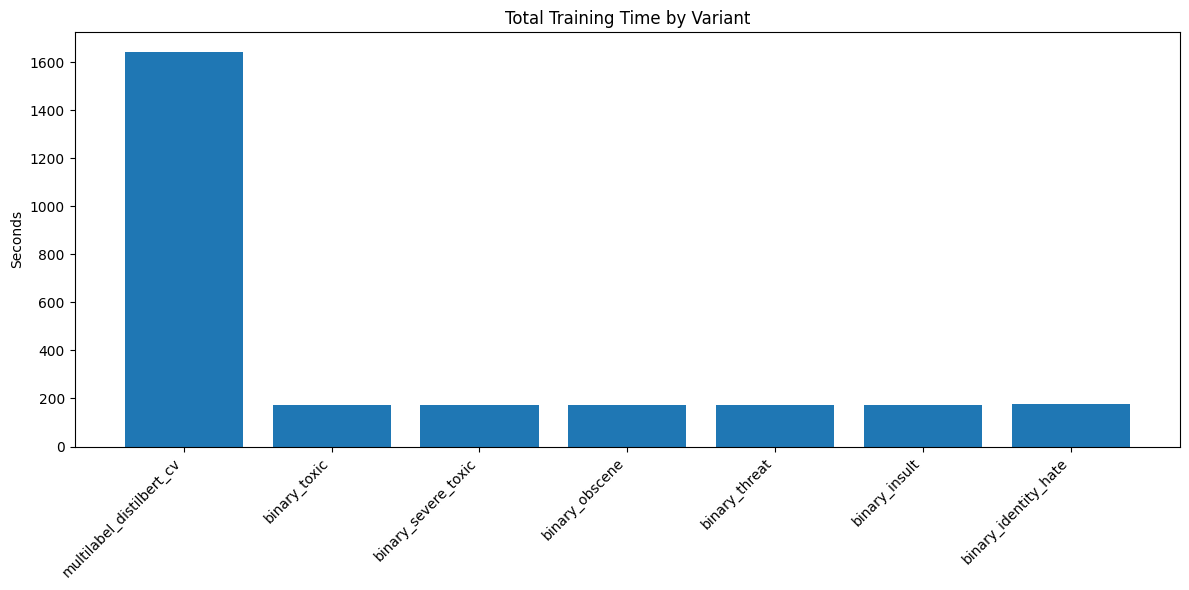

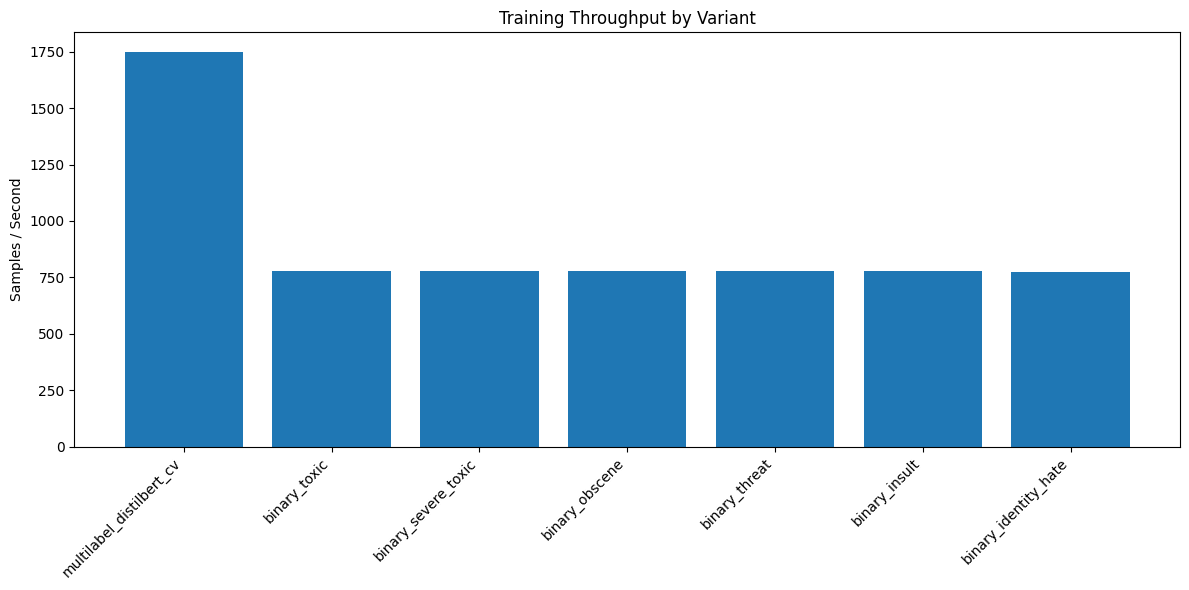

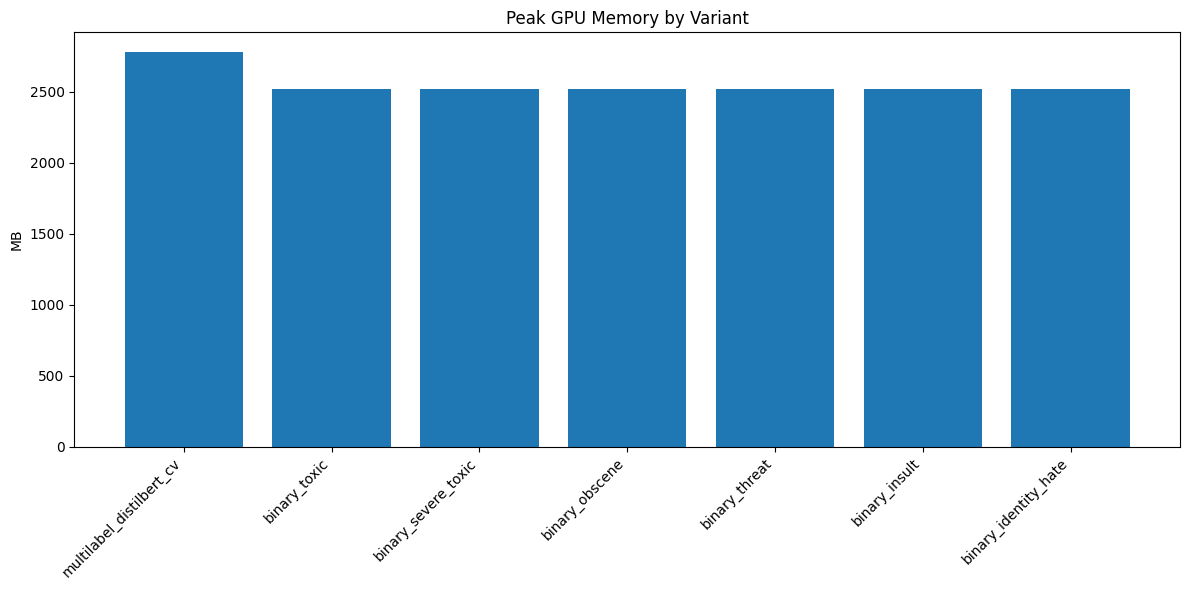

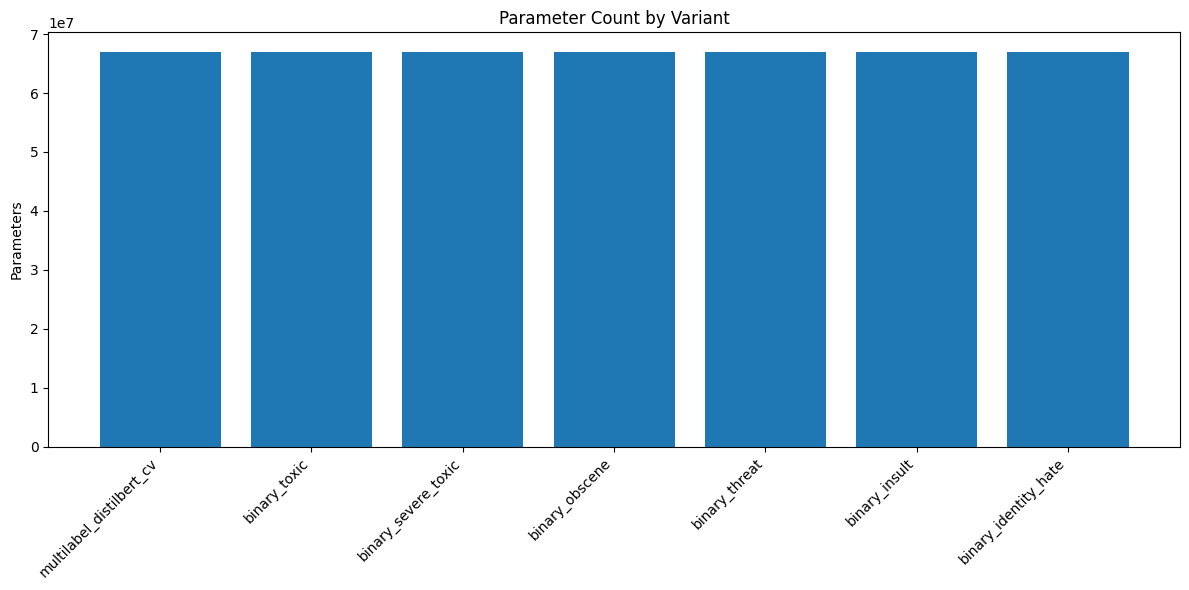

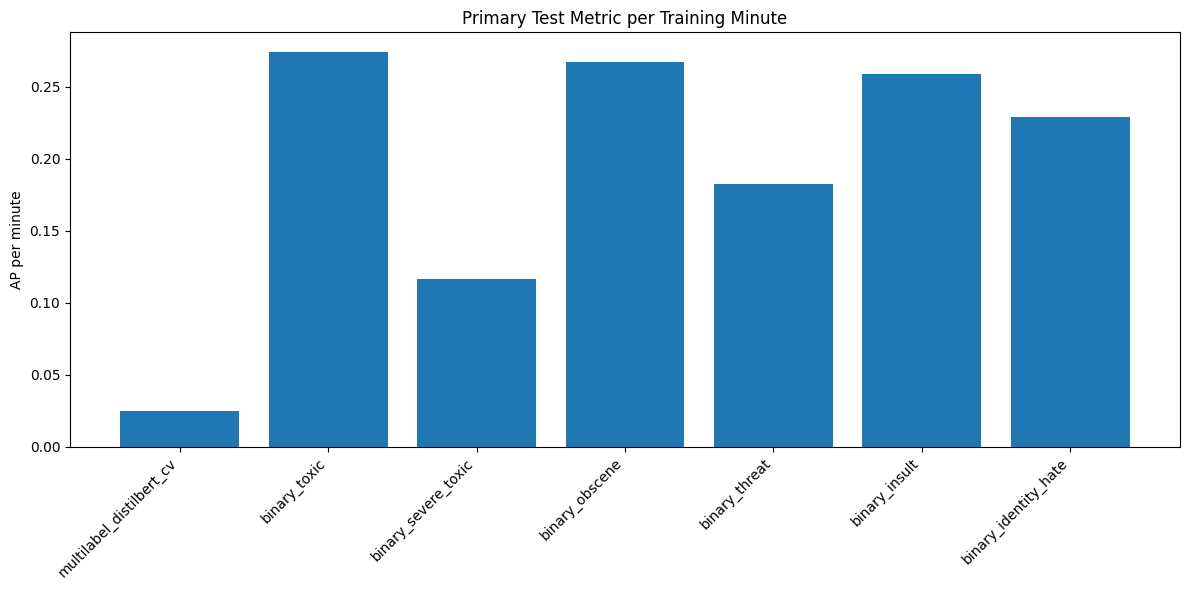

,variant_name,task_type,target_label,selection_metric,validation_main_metric,test_main_metric,total_train_seconds,avg_epoch_seconds,samples_per_second,max_gpu_memory_mb,parameter_count,trainable_parameter_count,ap_per_training_minute
0,multilabel_distilbert_cv,multilabel,None,validation_mean_average_precision,0.692910,0.680587,1642.632748,129.961978,1748.581966,2781.275879,66958086,66958086,0.024860
1,binary_toxic,binary,toxic,validation_average_precision,0.916349,0.796739,174.397278,165.150820,777.735762,2521.833008,66954241,66954241,0.274112
2,binary_severe_toxic,binary,severe_toxic,validation_average_precision,0.455167,0.337629,174.403421,165.431243,777.708369,2521.833008,66954241,66954241,0.116154
3,binary_obscene,binary,obscene,validation_average_precision,0.914608,0.777119,174.376733,165.320441,777.827394,2521.833008,66954241,66954241,0.267393
4,binary_threat,binary,threat,validation_average_precision,0.463052,0.530450,174.452324,165.449671,777.490357,2521.833008,66954241,66954241,0.182440
5,binary_insult,binary,insult,validation_average_precision,0.832402,0.754450,174.635254,165.450969,776.675940,2521.833008,66954241,66954241,0.259209
6,binary_identity_hate,binary,identity_hate,validation_average_precision,0.568737,0.667680,175.091733,165.779519,774.651078,2521.833008,66954241,66954241,0.228799


In [ ]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

summary_rows = []
for key in ["multilabel", "toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]:
    folder = FOLDERS[key]
    run_stats = load_json(os.path.join(folder, "run_stats.json"))
    run_config = load_json(os.path.join(folder, "run_config.json"))
    val_metrics = load_json(os.path.join(folder, "cv_validation_metrics_oof.json")) if key == "multilabel" else load_json(os.path.join(folder, "validation_metrics.json"))
    test_metrics = load_json(os.path.join(folder, "test_labeled_metrics.json"))

    row = {
        "variant_name": run_stats["variant_name"],
        "task_type": run_stats["task_type"],
        "target_label": run_stats["target_label"],
        "selection_metric": run_config["selection_metric"],
        "validation_main_metric": run_stats["validation_main_metric"],
        "test_main_metric": run_stats["test_main_metric"],
        "total_train_seconds": run_stats["total_train_seconds"],
        "avg_epoch_seconds": run_stats["avg_epoch_seconds"],
        "samples_per_second": run_stats["samples_per_second"],
        "max_gpu_memory_mb": run_stats["max_gpu_memory_mb"],
        "parameter_count": run_stats["parameter_count"],
        "trainable_parameter_count": run_stats["trainable_parameter_count"],
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(FOLDERS["experiment_summary"], "model_comparison_summary.csv"), index=False)
save_json(summary_df.to_dict(orient="records"), os.path.join(FOLDERS["experiment_summary"], "model_comparison_summary.json"))

plt.figure(figsize=(12, 6))
plt.bar(summary_df["variant_name"], summary_df["test_main_metric"])
plt.title("Primary Test Metric by Variant (Average Precision / Mean Average Precision)")
plt.ylabel("Primary test metric")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FOLDERS["experiment_summary"], "primary_test_metric_by_variant.png"), dpi=220)
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(summary_df["variant_name"], summary_df["total_train_seconds"])
plt.title("Total Training Time by Variant")
plt.ylabel("Seconds")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FOLDERS["cost_analysis"], "training_time_by_variant.png"), dpi=220)
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(summary_df["variant_name"], summary_df["samples_per_second"])
plt.title("Training Throughput by Variant")
plt.ylabel("Samples / Second")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FOLDERS["cost_analysis"], "throughput_by_variant.png"), dpi=220)
plt.show()

mem_df = summary_df.dropna(subset=["max_gpu_memory_mb"]).copy()
if len(mem_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.bar(mem_df["variant_name"], mem_df["max_gpu_memory_mb"])
    plt.title("Peak GPU Memory by Variant")
    plt.ylabel("MB")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(os.path.join(FOLDERS["cost_analysis"], "peak_gpu_memory_by_variant.png"), dpi=220)
    plt.show()

plt.figure(figsize=(12, 6))
plt.bar(summary_df["variant_name"], summary_df["parameter_count"])
plt.title("Parameter Count by Variant")
plt.ylabel("Parameters")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FOLDERS["cost_analysis"], "parameter_count_by_variant.png"), dpi=220)
plt.show()

summary_df["ap_per_training_minute"] = summary_df["test_main_metric"] / (summary_df["total_train_seconds"] / 60.0)

plt.figure(figsize=(12, 6))
plt.bar(summary_df["variant_name"], summary_df["ap_per_training_minute"])
plt.title("Primary Test Metric per Training Minute")
plt.ylabel("AP per minute")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FOLDERS["cost_analysis"], "ap_per_training_minute.png"), dpi=220)
plt.show()

summary_df

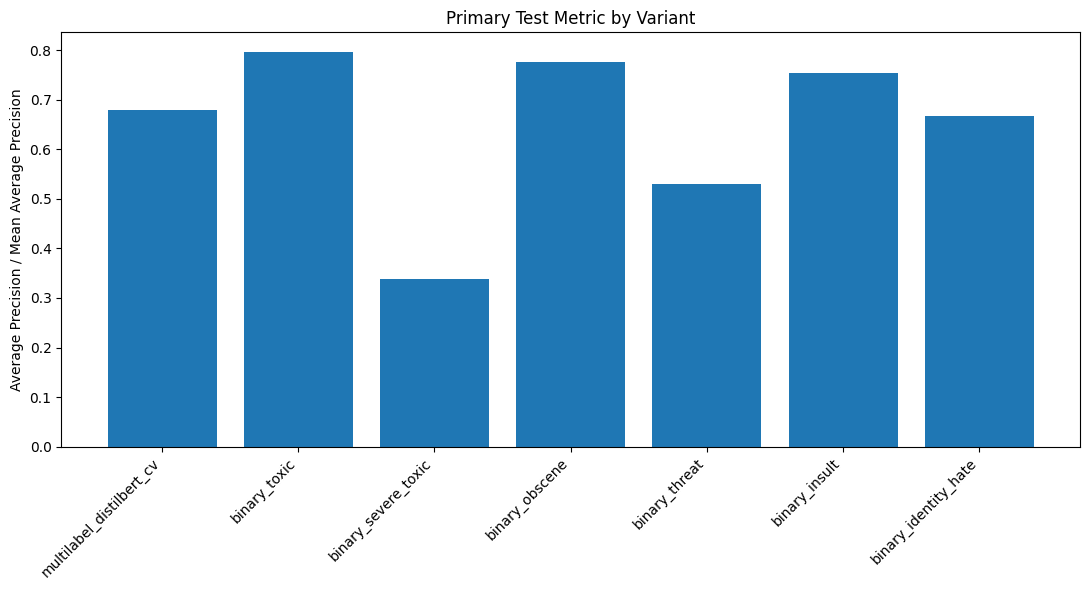

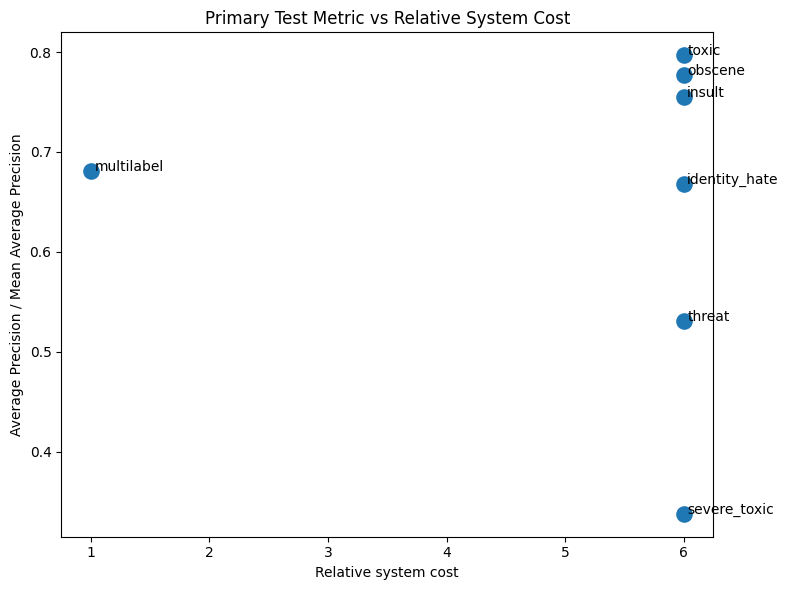

Saved overall summary files to: /content/QPData/NewOutputs/10_overall_summary


In [ ]:
def safe_float(x):
    if pd.isna(x):
        return None
    return float(x)

def classify_variant(row):
    return "shared_multilabel_model" if row["task_type"] == "multilabel" else "specialized_binary_model"

summary_df["variant_class"] = summary_df.apply(classify_variant, axis=1)

overall = {
    "project_section": "Transformer section of the larger toxic comment classification project",
    "purpose": (
        "This folder summarizes the transformer section of the larger toxic comment classification project. "
        "I use the shared multilabel DistilBERT run as the main transformer benchmark, "
        "and I keep the one-label binary runs as specialization checks."
    ),
    "execution_note": (
        "I ran the heavy transformer training in Google Colab or another GPU-backed setup. "
        "I do not treat full local CPU retraining as the normal workflow here."
    ),
    "how_to_read_the_main_metric": {
        "average_precision": "I use this as the main metric for the binary models.",
        "mean_average_precision": "I use this as the main metric for the shared multilabel model.",
        "why_not_f1": "I still save F1 at 0.5 for context, but I do not use it as the main selection metric."
    },
    "models": [],
}

for _, row in summary_df.iterrows():
    key = "multilabel" if row["task_type"] == "multilabel" else row["target_label"]
    folder = FOLDERS[key]
    run_config = load_json(os.path.join(folder, "run_config.json"))
    run_stats = load_json(os.path.join(folder, "run_stats.json"))
    val_metrics_path = os.path.join(folder, "cv_validation_metrics_oof.json") if row["task_type"] == "multilabel" else os.path.join(folder, "validation_metrics.json")
    val_metrics = load_json(val_metrics_path)
    test_metrics = load_json(os.path.join(folder, "test_labeled_metrics.json"))

    overall["models"].append({
        "variant_name": row["variant_name"],
        "variant_class": row["variant_class"],
        "task_type": row["task_type"],
        "target_label": None if pd.isna(row["target_label"]) else row["target_label"],
        "selection_metric": run_config["selection_metric"],
        "validation_main_metric": run_stats["validation_main_metric"],
        "test_main_metric": run_stats["test_main_metric"],
        "training_time_minutes": run_stats["total_train_seconds"] / 60.0,
        "samples_per_second": run_stats["samples_per_second"],
        "max_gpu_memory_mb": run_stats["max_gpu_memory_mb"],
        "parameter_count": run_stats["parameter_count"],
        "plain_english_summary": (
            "I train one shared transformer across all six labels and pick it by validation mean average precision."
            if row["task_type"] == "multilabel"
            else f"I train one transformer just for {row['target_label']} and pick it by validation average precision."
        ),
        "validation_metrics_full": val_metrics,
        "test_metrics_full": test_metrics,
    })

multilabel_row = summary_df[summary_df["task_type"] == "multilabel"].iloc[0]
binary_rows = summary_df[summary_df["task_type"] == "binary"].copy()

overall["high_level_findings"] = {
    "shared_model_test_mean_average_precision": safe_float(multilabel_row["test_main_metric"]),
    "average_binary_test_average_precision": safe_float(binary_rows["test_main_metric"].mean()),
    "best_binary_model": binary_rows.sort_values("test_main_metric", ascending=False).iloc[0][["variant_name", "target_label", "test_main_metric"]].to_dict(),
    "recommended_interpretation": [
        "I treat the shared multilabel CV model as the main transformer benchmark.",
        "I use the binary models as label-specific follow-up checks.",
        "In the full project, these transformer runs are only one modeling section, not the whole story."
    ]
}

save_json(overall, os.path.join(FOLDERS["overall_summary"], "overall_handoff_summary.json"))

readme_text = f"""# 10_overall_summary

I use this folder as the quick read for the transformer section of the larger toxic comment classification project.

What I would open first
1. `overall_handoff_summary.json`
2. `overall_primary_metric_comparison.png`
3. `overall_cost_vs_metric.png`

Notes
- I treat the shared multilabel run as the main transformer benchmark.
- I keep the six binary runs as label-specific follow-up checks.
- The heavy transformer training was done in Colab or another GPU-backed setup, so I do not assume a full local CPU rerun here.
"""

with open(os.path.join(FOLDERS["overall_summary"], "README.md"), "w") as f:
    f.write(readme_text)

plt.figure(figsize=(11, 6))
plt.bar(summary_df["variant_name"], summary_df["test_main_metric"])
plt.title("Primary Test Metric by Variant")
plt.ylabel("Average Precision / Mean Average Precision")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FOLDERS["overall_summary"], "overall_primary_metric_comparison.png"), dpi=220)
plt.show()

cost_plot = summary_df.copy()
cost_plot["relative_system_cost"] = cost_plot["task_type"].apply(lambda x: 1 if x == "multilabel" else 6)

plt.figure(figsize=(8, 6))
plt.scatter(cost_plot["relative_system_cost"], cost_plot["test_main_metric"], s=120)
for _, r in cost_plot.iterrows():
    label = "multilabel" if r["task_type"] == "multilabel" else str(r["target_label"])
    plt.text(r["relative_system_cost"] + 0.03, r["test_main_metric"], label)
plt.title("Primary Test Metric vs Relative System Cost")
plt.xlabel("Relative system cost")
plt.ylabel("Average Precision / Mean Average Precision")
plt.tight_layout()
plt.savefig(os.path.join(FOLDERS["overall_summary"], "overall_cost_vs_metric.png"), dpi=220)
plt.show()

print("Saved overall summary files to:", FOLDERS["overall_summary"])

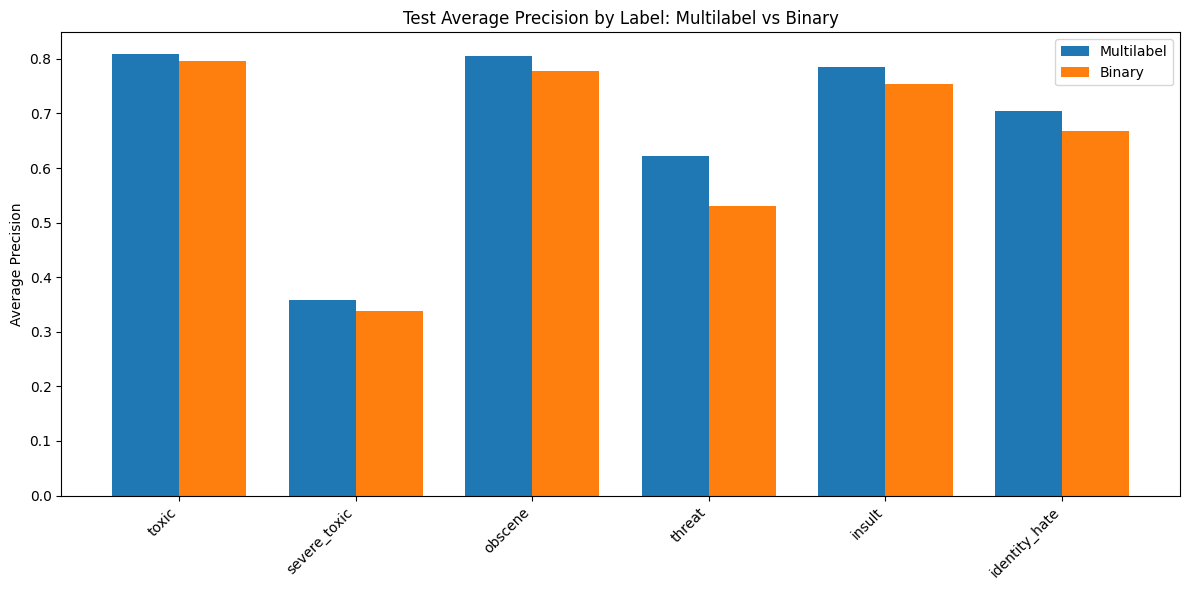

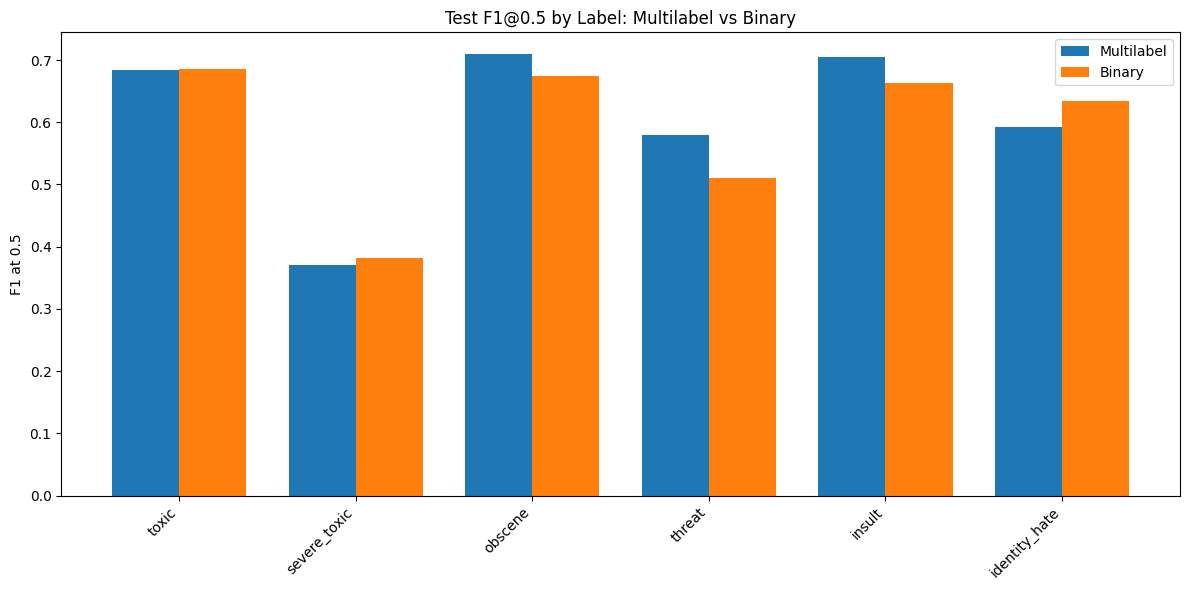

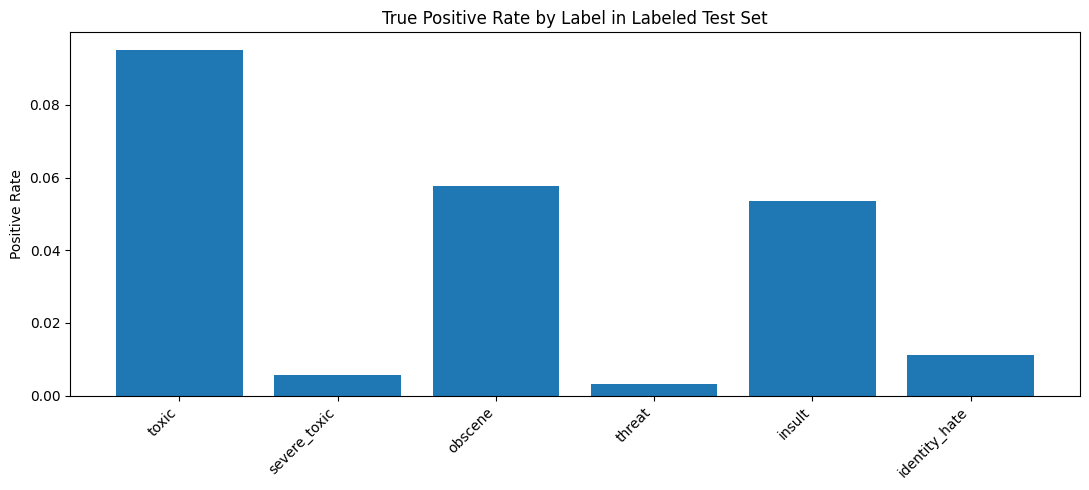

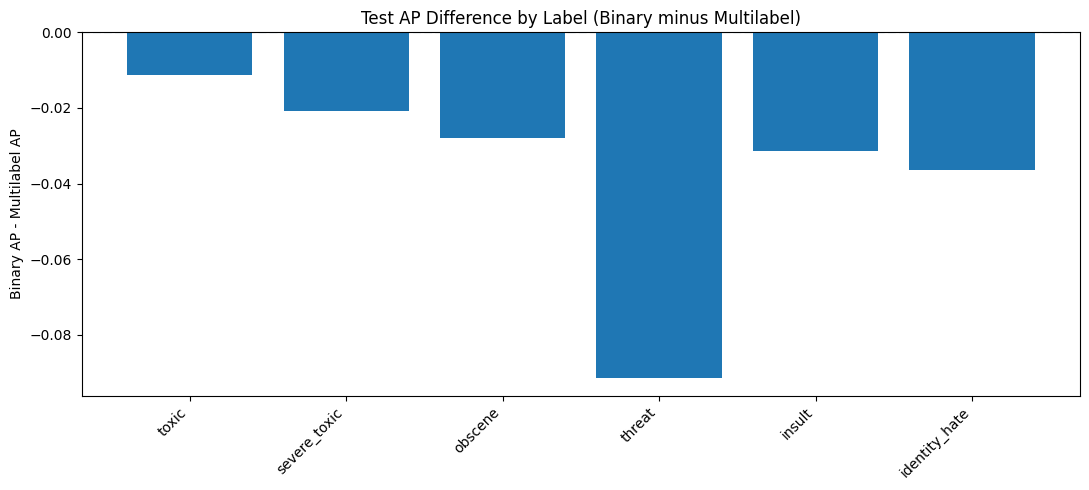

Saved 11_test_results to: /content/QPData/NewOutputs/11_test_results

Files:
- ap_by_label_multilabel_vs_binary.png
- ap_delta_binary_minus_multilabel.png
- binary_test_metrics_by_label.csv
- binary_test_summary.json
- f1_by_label_multilabel_vs_binary.png
- multilabel_test_metrics_by_label.csv
- multilabel_test_summary.json
- multilabel_vs_binary_test_comparison.csv
- overall_test_results_summary.json
- test_label_prevalence.png


In [ ]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
)

TEST_RESULTS_DIR = os.path.join(OUTPUT_ROOT, "11_test_results")
os.makedirs(TEST_RESULTS_DIR, exist_ok=True)

# I keep one small helper here for the test metrics.
def safe_metric(fn, y_true, y_score_or_pred):
    try:
        return float(fn(y_true, y_score_or_pred))
    except Exception:
        return None

# I score the shared multilabel outputs first.
multilabel_test_path = os.path.join(FOLDERS["multilabel"], "test_labeled_predictions.csv")
ml_df = pd.read_csv(multilabel_test_path)

multilabel_rows = []
ml_ap_values = []
ml_auc_values = []
ml_f1_values = []

for label in LABEL_COLS:
    y_true = ml_df[f"{label}_true"].values.astype(int)
    y_prob = ml_df[f"{label}_prob"].values.astype(float)

    # I handle either the newer pred_at_0_5 columns or the older pred columns.
    pred_col = f"{label}_pred_at_0_5" if f"{label}_pred_at_0_5" in ml_df.columns else label
    y_pred = ml_df[pred_col].values.astype(int)

    ap = safe_metric(average_precision_score, y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    auc = safe_metric(roc_auc_score, y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    prec = safe_metric(lambda a, b: precision_score(a, b, zero_division=0), y_true, y_pred)
    rec = safe_metric(lambda a, b: recall_score(a, b, zero_division=0), y_true, y_pred)
    f1 = safe_metric(lambda a, b: f1_score(a, b, zero_division=0), y_true, y_pred)

    multilabel_rows.append({
        "model_family": "multilabel",
        "label": label,
        "average_precision": ap,
        "roc_auc": auc,
        "precision_at_0_5": prec,
        "recall_at_0_5": rec,
        "f1_at_0_5": f1,
        "positive_rate_true": float(np.mean(y_true)),
        "positive_rate_pred_at_0_5": float(np.mean(y_pred)),
    })

    if ap is not None:
        ml_ap_values.append(ap)
    if auc is not None:
        ml_auc_values.append(auc)
    if f1 is not None:
        ml_f1_values.append(f1)

multilabel_table = pd.DataFrame(multilabel_rows)
multilabel_table.to_csv(os.path.join(TEST_RESULTS_DIR, "multilabel_test_metrics_by_label.csv"), index=False)

multilabel_summary = {
    "model_family": "multilabel",
    "graded_against": "test_labeled_cleaned.parquet",
    "primary_metric": "mean_average_precision",
    "mean_average_precision": float(np.mean(ml_ap_values)) if len(ml_ap_values) > 0 else None,
    "mean_roc_auc": float(np.mean(ml_auc_values)) if len(ml_auc_values) > 0 else None,
    "macro_f1_at_0_5": float(np.mean(ml_f1_values)) if len(ml_f1_values) > 0 else None,
    "per_label": multilabel_rows,
}

with open(os.path.join(TEST_RESULTS_DIR, "multilabel_test_summary.json"), "w") as f:
    json.dump(multilabel_summary, f, indent=2)

# I score the six one-label runs next.
binary_folder_map = {
    "toxic": FOLDERS["toxic"],
    "severe_toxic": FOLDERS["severe_toxic"],
    "obscene": FOLDERS["obscene"],
    "threat": FOLDERS["threat"],
    "insult": FOLDERS["insult"],
    "identity_hate": FOLDERS["identity_hate"],
}

binary_rows = []

for label, folder in binary_folder_map.items():
    path = os.path.join(folder, "test_labeled_predictions.csv")
    df = pd.read_csv(path)

    y_true = df[f"{label}_true"].values.astype(int)
    y_prob = df[f"{label}_prob"].values.astype(float)

    pred_col = f"{label}_pred_at_0_5" if f"{label}_pred_at_0_5" in df.columns else f"{label}_pred"
    y_pred = df[pred_col].values.astype(int)

    ap = safe_metric(average_precision_score, y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    auc = safe_metric(roc_auc_score, y_true, y_prob) if len(np.unique(y_true)) > 1 else None
    prec = safe_metric(lambda a, b: precision_score(a, b, zero_division=0), y_true, y_pred)
    rec = safe_metric(lambda a, b: recall_score(a, b, zero_division=0), y_true, y_pred)
    f1 = safe_metric(lambda a, b: f1_score(a, b, zero_division=0), y_true, y_pred)

    binary_rows.append({
        "model_family": "binary",
        "label": label,
        "average_precision": ap,
        "roc_auc": auc,
        "precision_at_0_5": prec,
        "recall_at_0_5": rec,
        "f1_at_0_5": f1,
        "positive_rate_true": float(np.mean(y_true)),
        "positive_rate_pred_at_0_5": float(np.mean(y_pred)),
    })

binary_table = pd.DataFrame(binary_rows)
binary_table.to_csv(os.path.join(TEST_RESULTS_DIR, "binary_test_metrics_by_label.csv"), index=False)

binary_summary = {
    "model_family": "binary",
    "graded_against": "test_labeled_cleaned.parquet",
    "primary_metric": "average_precision",
    "mean_average_precision_across_binary_models": float(binary_table["average_precision"].mean()),
    "mean_roc_auc_across_binary_models": float(binary_table["roc_auc"].mean()),
    "mean_f1_at_0_5_across_binary_models": float(binary_table["f1_at_0_5"].mean()),
    "per_label": binary_rows,
}

with open(os.path.join(TEST_RESULTS_DIR, "binary_test_summary.json"), "w") as f:
    json.dump(binary_summary, f, indent=2)

# I save one joined comparison table.
combined = multilabel_table.merge(
    binary_table,
    on="label",
    how="outer",
    suffixes=("_multilabel", "_binary")
)
combined.to_csv(os.path.join(TEST_RESULTS_DIR, "multilabel_vs_binary_test_comparison.csv"), index=False)

# I save a few quick comparison charts.

# I compare AP by label.
x = np.arange(len(LABEL_COLS))
width = 0.38

ml_ap_plot = [multilabel_table.loc[multilabel_table["label"] == lbl, "average_precision"].iloc[0] for lbl in LABEL_COLS]
bin_ap_plot = [binary_table.loc[binary_table["label"] == lbl, "average_precision"].iloc[0] for lbl in LABEL_COLS]

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, ml_ap_plot, width=width, label="Multilabel")
plt.bar(x + width/2, bin_ap_plot, width=width, label="Binary")
plt.xticks(x, LABEL_COLS, rotation=45, ha="right")
plt.ylabel("Average Precision")
plt.title("Test Average Precision by Label: Multilabel vs Binary")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(TEST_RESULTS_DIR, "ap_by_label_multilabel_vs_binary.png"), dpi=220)
plt.show()

# I compare F1 at 0.5 by label.
ml_f1_plot = [multilabel_table.loc[multilabel_table["label"] == lbl, "f1_at_0_5"].iloc[0] for lbl in LABEL_COLS]
bin_f1_plot = [binary_table.loc[binary_table["label"] == lbl, "f1_at_0_5"].iloc[0] for lbl in LABEL_COLS]

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, ml_f1_plot, width=width, label="Multilabel")
plt.bar(x + width/2, bin_f1_plot, width=width, label="Binary")
plt.xticks(x, LABEL_COLS, rotation=45, ha="right")
plt.ylabel("F1 at 0.5")
plt.title("Test F1@0.5 by Label: Multilabel vs Binary")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(TEST_RESULTS_DIR, "f1_by_label_multilabel_vs_binary.png"), dpi=220)
plt.show()

# I show label prevalence in the labeled test split.
true_rates = [multilabel_table.loc[multilabel_table["label"] == lbl, "positive_rate_true"].iloc[0] for lbl in LABEL_COLS]

plt.figure(figsize=(11, 5))
plt.bar(LABEL_COLS, true_rates)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Positive Rate")
plt.title("True Positive Rate by Label in Labeled Test Set")
plt.tight_layout()
plt.savefig(os.path.join(TEST_RESULTS_DIR, "test_label_prevalence.png"), dpi=220)
plt.show()

# I show binary AP minus multilabel AP.
ap_delta = [b - m for m, b in zip(ml_ap_plot, bin_ap_plot)]

plt.figure(figsize=(11, 5))
plt.bar(LABEL_COLS, ap_delta)
plt.axhline(0, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Binary AP - Multilabel AP")
plt.title("Test AP Difference by Label (Binary minus Multilabel)")
plt.tight_layout()
plt.savefig(os.path.join(TEST_RESULTS_DIR, "ap_delta_binary_minus_multilabel.png"), dpi=220)
plt.show()

# I save one compact overall summary JSON.
overall_test_results = {
    "graded_against": "test_labeled_cleaned.parquet",
    "primary_comparison": "average_precision",
    "multilabel_summary": multilabel_summary,
    "binary_summary": binary_summary,
    "high_level_takeaways": [
        "Average precision is the main threshold-free comparison metric.",
        "F1 at 0.5 is included only as a secondary diagnostic.",
        "Labels where binary AP exceeds multilabel AP are candidates for specialization wins.",
        "Labels where multilabel AP is similar or better support the shared-model approach."
    ]
}

with open(os.path.join(TEST_RESULTS_DIR, "overall_test_results_summary.json"), "w") as f:
    json.dump(overall_test_results, f, indent=2)

print("Saved 11_test_results to:", TEST_RESULTS_DIR)
print("\nFiles:")
for fn in sorted(os.listdir(TEST_RESULTS_DIR)):
    print("-", fn)